In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

In [3]:
import sys
sys.path.append("/home/563/as8561/side_projects/extreme_el_nino_2026/")

In [4]:
from functions import preproc_funcs as funcs

In [5]:
# xr.open_dataset('/g/data/**/replicas/CMIP6/CMIP/**/**/historical/r10i1p1f1/Amon/ts/gn/**/*.nc')
# xr.open_dataset('/g/data/**/replicas/CMIP6/CMIP/**/**/piControl/r1i1p1f1/Amon/ts/gn/**/*.nc')
# xr.open_dataset('/g/data/**/replicas/CMIP6/ScenarioMIP/**/**/ssp585/r10i1p1f1/Amon/tas/gn/**/*.nc')
# xr.open_dataset('/g/data/**/replicas/CMIP6/CMIP/**/**/abrupt-4xCO2/r1i1p1f1/Amon/ts/gn/**/*.nc')

In [6]:
import gzip
from pathlib import Path


In [21]:
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 7,
    "axes.titlesize": 8, "axes.labelsize": 7,
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "legend.fontsize": 8.5,
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "xtick.major.size": 2.5, "ytick.major.size": 2.5,
    "xtick.direction": "out", "ytick.direction": "out",
    "axes.spines.top": False, "axes.spines.right": False,
    "lines.linewidth": 1.0,
    "savefig.dpi": 600, "figure.dpi": 150,
    "savefig.bbox": "tight", "pdf.fonttype": 42, "ps.fonttype": 42,  # editable text in Illustrator
})

MM = 1/25.4
SINGLE_COL = 89 * MM      # Nature single column
DOUBLE_COL = 183 * MM     # Nature double column

In [13]:
import glob, os
from collections import defaultdict

VARIANT = "r1i1p1f1"
GRIDS   = ["gn", "gr", "gr1"]

def parse(path):
    p = path.split("/"); i = p.index("historical"); j = p.index("ts", i)
    return p[i-1], p[j+1], p[j+2]                 # model, grid, version

tree = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
for g in GRIDS:
    for f in glob.glob(f"/g/data/*/*/CMIP6/CMIP/*/*/historical/{VARIANT}/Amon/ts/{g}/*/*.nc"):
        m, grid, ver = parse(f)
        tree[m][grid][ver].append(f)

hist = {}
for m, grids in tree.items():
    grid = next(g for g in GRIDS if g in grids)   # prefer gn > gr > gr1
    ver  = sorted(grids[grid])[-1]                # latest version
    hist[m] = dict(grid=grid, version=ver, files=sorted(grids[grid][ver]))

print(f"{len(hist)} models\n")
for m in sorted(hist):
    print(f"  {m:28s} {hist[m]['grid']:4s} {len(hist[m]['files'])} files")

53 models

  ACCESS-CM2                   gn   1 files
  ACCESS-ESM1-5                gn   1 files
  AWI-CM-1-1-MR                gn   165 files
  AWI-ESM-1-1-LR               gn   165 files
  BCC-CSM2-MR                  gn   1 files
  BCC-ESM1                     gn   1 files
  CAMS-CSM1-0                  gn   1 files
  CAS-ESM2-0                   gn   1 files
  CESM2                        gn   1 files
  CESM2-FV2                    gn   4 files
  CESM2-WACCM                  gn   1 files
  CESM2-WACCM-FV2              gn   4 files
  CIESM                        gr   1 files
  CMCC-CM2-HR4                 gn   1 files
  CMCC-CM2-SR5                 gn   1 files
  CMCC-ESM2                    gn   1 files
  CanESM5                      gn   1 files
  E3SM-1-0                     gr   7 files
  E3SM-1-1                     gr   17 files
  E3SM-1-1-ECA                 gr   17 files
  EC-Earth3                    gr   165 files
  EC-Earth3-CC                 gr   165 files
  EC-Earth3

In [14]:
import regionmask, numpy as np, pandas as pd, xarray as xr
from scipy.stats import skew
from tqdm.auto import tqdm

try:    _LAND = regionmask.defined_regions.natural_earth_v5_0_0.land_110
except AttributeError: _LAND = regionmask.defined_regions.natural_earth.land_110

def load_ts(m):
    ds = xr.open_mfdataset(hist[m]["files"], combine="by_coords",
                           use_cftime=True, chunks={"time": 120})
    da = ds["ts"]
    ren = {}
    for c in list(da.coords):
        cl = c.lower()
        if cl in ("latitude", "lat", "y"):  ren[c] = "lat"
        elif cl in ("longitude", "lon", "x"): ren[c] = "lon"
    da = da.rename(ren).assign_coords()          # ensure names
    da = da.assign_coords(lon=(da["lon"] % 360)).sortby("lon").sortby("lat")
    return da.sel(time=slice("1900", "2000"))

def rel_n34(da, ocean):
    n34  = da.sel(lat=slice(-5, 5), lon=slice(190, 240))
    n34  = n34.weighted(np.cos(np.deg2rad(n34.lat))).mean(("lat", "lon"))
    band = da.sel(lat=slice(-20, 20)); ob = ocean.sel(lat=slice(-20, 20))
    trp  = band.where(ob).weighted(np.cos(np.deg2rad(band.lat))).mean(("lat", "lon"))
    n34a = n34.groupby("time.month") - n34.groupby("time.month").mean("time")
    trpa = trp.groupby("time.month") - trp.groupby("time.month").mean("time")
    return (n34a - trpa).rolling(time=3, center=True).mean()

model_skew = {}
for m in tqdm(sorted(hist)):
    try:
        da    = load_ts(m)
        ocean = np.isnan(_LAND.mask(da.lon, da.lat))          # True over ocean
        rel   = rel_n34(da, ocean).compute().dropna("time")   # only the 1-D series is read
        model_skew[m] = float(skew(rel.values))
    except Exception as e:
        tqdm.write(f"  {m:24s} SKIP {type(e).__name__}: {str(e)[:60]}")

sk = pd.Series(model_skew).sort_values()
print(f"\n{len(sk)} models with skewness:\n")
print(sk.round(3).to_string())

  0%|          | 0/53 [00:00<?, ?it/s]

  ICON-ESM-LR              SKIP KeyError: "no index found for coordinate 'lat'"

52 models with skewness:

ACCESS-ESM1-5       -0.504
BCC-CSM2-MR         -0.502
IITM-ESM            -0.443
FGOALS-g3           -0.441
GISS-E2-1-G-CC      -0.320
ACCESS-CM2          -0.311
NorCPM1             -0.307
CAMS-CSM1-0         -0.251
BCC-ESM1            -0.211
MPI-ESM1-2-HR       -0.197
FGOALS-f3-L         -0.187
KIOST-ESM           -0.172
IPSL-CM6A-LR-INCA   -0.165
AWI-ESM-1-1-LR      -0.164
GISS-E2-1-G         -0.163
IPSL-CM5A2-INCA     -0.127
NorESM2-LM          -0.095
INM-CM5-0           -0.077
NorESM2-MM          -0.067
EC-Earth3-CC        -0.064
CAS-ESM2-0          -0.041
GFDL-ESM4           -0.040
CESM2               -0.005
KACE-1-0-G           0.017
E3SM-1-1             0.030
AWI-CM-1-1-MR        0.052
CanESM5              0.061
CESM2-FV2            0.077
GFDL-CM4             0.104
GISS-E2-1-H          0.151
INM-CM4-8            0.171
E3SM-1-0             0.173
IPSL-CM6A-LR         0.182
CE

In [15]:
import gzip
from pathlib import Path

obs_dir  = Path("/g/data/if69/as8561/data/obs_SST_products")
obs_files = {"COBE": "COBE_sst.mon.mean.nc", "DCSST": "DCSST-I_mean_1x1.nc",
             "HadISST": "HadISST_sst.nc.gz", "ERSSTv5": "ersst_v5.nc"}

def open_obs(n):
    p = obs_dir / obs_files[n]
    if str(p).endswith(".gz"):
        with gzip.open(p) as f: return xr.open_dataset(f).load()
    return xr.open_dataset(p)

def std_obs(ds):
    v  = "tos" if "tos" in ds.data_vars else "sst"
    da = ds[v]
    ren = {}
    for c in da.coords:
        cl = c.lower()
        if cl in ("latitude","lat","y"):  ren[c] = "lat"
        if cl in ("longitude","lon","x"): ren[c] = "lon"
    da = da.rename(ren).squeeze(drop=True)
    da = da.assign_coords(lon=(da.lon % 360)).sortby("lon").sortby("lat")
    return da.where((da > -5) & (da < 45))

def obs_rel_skew(n):
    da  = std_obs(open_obs(n)).sel(time=slice("1900", "2000"))
    n34 = da.sel(lat=slice(-5,5), lon=slice(190,240))
    n34 = n34.weighted(np.cos(np.deg2rad(n34.lat))).mean(("lat","lon"), skipna=True)
    bnd = da.sel(lat=slice(-20,20))
    trp = bnd.weighted(np.cos(np.deg2rad(bnd.lat))).mean(("lat","lon"), skipna=True)
    n34a = n34.groupby("time.month") - n34.groupby("time.month").mean("time")
    trpa = trp.groupby("time.month") - trp.groupby("time.month").mean("time")
    rel  = (n34a - trpa).rolling(time=3, center=True).mean().dropna("time")
    return float(skew(rel.values))

obs_skew = {n: obs_rel_skew(n) for n in obs_files}
obs_lo, obs_hi = min(obs_skew.values()), max(obs_skew.values())
print("observed relative-Niño3.4 skewness (1900–2000):")
for n, s in obs_skew.items(): print(f"  {n:8s} {s:+.3f}")
print(f"\nobserved envelope: {obs_lo:+.3f} to {obs_hi:+.3f}")

observed relative-Niño3.4 skewness (1900–2000):
  COBE     +0.174
  DCSST    +0.390
  HadISST  +0.080
  ERSSTv5  +0.319

observed envelope: +0.080 to +0.390


In [17]:
gate = [m for m, s in model_skew.items() if obs_lo <= s <= obs_hi]
print(f"{len(gate)} models pass the skewness gate [{obs_lo:+.2f}, {obs_hi:+.2f}]:\n")
for m in sorted(gate, key=lambda x: model_skew[x]):
    print(f"  {m:22s} {model_skew[m]:+.3f}")
print("\nrejected — too SYMMETRIC/negative:",
      ", ".join(sorted((m for m, s in model_skew.items() if s < obs_lo), key=lambda x: model_skew[x])))
print("\nrejected — too SKEWED:",
      ", ".join(sorted((m for m, s in model_skew.items() if s > obs_hi), key=lambda x: model_skew[x])))

15 models pass the skewness gate [+0.08, +0.39]:

  GFDL-CM4               +0.104
  GISS-E2-1-H            +0.151
  INM-CM4-8              +0.171
  E3SM-1-0               +0.173
  IPSL-CM6A-LR           +0.182
  CESM2-WACCM-FV2        +0.187
  CESM2-WACCM            +0.192
  MPI-ESM1-2-LR          +0.192
  E3SM-1-1-ECA           +0.195
  SAM0-UNICON            +0.235
  CMCC-CM2-HR4           +0.246
  MRI-ESM2-0             +0.256
  EC-Earth3-Veg-LR       +0.314
  NESM3                  +0.357
  FIO-ESM-2-0            +0.377

rejected — too SYMMETRIC/negative: ACCESS-ESM1-5, BCC-CSM2-MR, IITM-ESM, FGOALS-g3, GISS-E2-1-G-CC, ACCESS-CM2, NorCPM1, CAMS-CSM1-0, BCC-ESM1, MPI-ESM1-2-HR, FGOALS-f3-L, KIOST-ESM, IPSL-CM6A-LR-INCA, AWI-ESM-1-1-LR, GISS-E2-1-G, IPSL-CM5A2-INCA, NorESM2-LM, INM-CM5-0, NorESM2-MM, EC-Earth3-CC, CAS-ESM2-0, GFDL-ESM4, CESM2, KACE-1-0-G, E3SM-1-1, AWI-CM-1-1-MR, CanESM5, CESM2-FV2

rejected — too SKEWED: MIROC6, EC-Earth3, MPI-ESM-1-2-HAM, TaiESM1, EC-Earth3-Veg, CI

In [18]:
def discover(activity, experiment, variant="r1i1p1f1", grids=("gn","gr","gr1")):
    found = {}
    for g in grids:
        pat = f"/g/data/*/replicas/CMIP6/{activity}/*/*/{experiment}/{variant}/Amon/ts/{g}/*/*.nc"
        for f in glob.glob(pat):
            p = f.split("/"); i = p.index(experiment); j = p.index("ts", i)
            found.setdefault(p[i-1], {}).setdefault(p[j+1], {}).setdefault(p[j+2], []).append(f)
    out = {}
    for m, gr in found.items():
        grid = next(gg for gg in grids if gg in gr)
        ver  = sorted(gr[grid])[-1]
        out[m] = dict(grid=grid, version=ver, files=sorted(gr[grid][ver]))
    return out

exps  = {"piControl": ("CMIP","piControl"), "abrupt-4xCO2": ("CMIP","abrupt-4xCO2"),
         "ssp245": ("ScenarioMIP","ssp245"), "ssp585": ("ScenarioMIP","ssp585")}
avail = {name: discover(act, exp) for name, (act, exp) in exps.items()}

tab = pd.DataFrame({name: {m: (m in a) for m in gate} for name, a in avail.items()})
tab.insert(0, "historical", True)
print("experiment availability (gated models, r1i1p1f1):\n")
print(tab.loc[sorted(gate)].replace({True: "\u2713", False: "\u2014"}).to_string())
print("\ncomplete (all 4 forced exps):",
      [m for m in gate if all(m in avail[e] for e in exps)])

experiment availability (gated models, r1i1p1f1):

                 historical piControl abrupt-4xCO2 ssp245 ssp585
CESM2-WACCM               ✓         ✓            ✓      ✓      ✓
CESM2-WACCM-FV2           ✓         ✓            ✓      —      —
CMCC-CM2-HR4              ✓         —            ✓      —      —
E3SM-1-0                  ✓         ✓            ✓      —      —
E3SM-1-1-ECA              ✓         ✓            —      —      —
EC-Earth3-Veg-LR          ✓         ✓            —      ✓      ✓
FIO-ESM-2-0               ✓         ✓            ✓      ✓      ✓
GFDL-CM4                  ✓         ✓            ✓      ✓      ✓
GISS-E2-1-H               ✓         ✓            ✓      —      —
INM-CM4-8                 ✓         ✓            ✓      ✓      ✓
IPSL-CM6A-LR              ✓         ✓            ✓      ✓      ✓
MPI-ESM1-2-LR             ✓         ✓            ✓      ✓      ✓
MRI-ESM2-0                ✓         ✓            ✓      ✓      ✓
NESM3                     ✓         ✓  

In [19]:
# standardize each series (z-score) for comparison using kdeplot to avoid amplitude differences and nly see differences in shape
model_rel = {}
for m in tqdm(sorted(hist)):
    try:
        da    = load_ts(m)
        ocean = np.isnan(_LAND.mask(da.lon, da.lat))
        r     = rel_n34(da, ocean).compute().dropna("time").values
        model_rel[m] = (r - r.mean()) / r.std()          # z-score → compares shape
    except Exception as e:
        tqdm.write(f"  {m} SKIP {type(e).__name__}")

def obs_series(n):
    da  = std_obs(open_obs(n)).sel(time=slice("1900", "2000"))
    n34 = da.sel(lat=slice(-5,5), lon=slice(190,240))
    n34 = n34.weighted(np.cos(np.deg2rad(n34.lat))).mean(("lat","lon"), skipna=True)
    bnd = da.sel(lat=slice(-20,20))
    trp = bnd.weighted(np.cos(np.deg2rad(bnd.lat))).mean(("lat","lon"), skipna=True)
    n34a = n34.groupby("time.month") - n34.groupby("time.month").mean("time")
    trpa = trp.groupby("time.month") - trp.groupby("time.month").mean("time")
    r = (n34a - trpa).rolling(time=3, center=True).mean().dropna("time").values
    return (r - r.mean()) / r.std()

obs_rel = {n: obs_series(n) for n in obs_files}
print("stored:", len(model_rel), "models,", len(obs_rel), "obs products")

  0%|          | 0/53 [00:00<?, ?it/s]

  ICON-ESM-LR SKIP KeyError
stored: 52 models, 4 obs products


In [49]:
import json
f2026 = json.load(open("/g/data/if69/as8561/data/f2026_roni_forecast.json"))
# z-scored axes → express forecast in std units (mean≈0, std = SIGMA_OBS)
zc, zlo, zhi = (f2026[k] / SIGMA_OBS for k in ("best", "low", "high"))
print(f"forecast in std units: central {zc:.2f}  ({zlo:.2f}–{zhi:.2f})")

forecast in std units: central 3.71  (2.82–5.04)


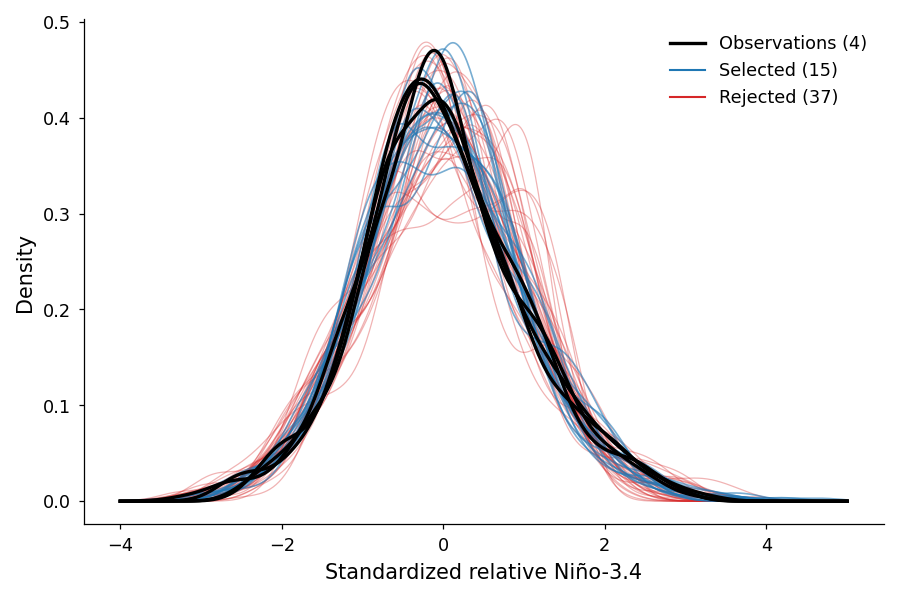

In [52]:
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

xg = np.linspace(-4, 5, 500)
fig, ax = plt.subplots(figsize=(6, 4))

for m, s in model_rel.items():                                   # rejected
    if m not in gate:
        ax.plot(xg, gaussian_kde(s)(xg), color="tab:red",  lw=0.6, alpha=0.35)
for m in gate:                                                   # selected
    if m in model_rel:
        ax.plot(xg, gaussian_kde(model_rel[m])(xg), color="tab:blue", lw=0.8, alpha=0.6)
for n, s in obs_rel.items():                                    # observations
    ax.plot(xg, gaussian_kde(s)(xg), color="k", lw=1.6)

from matplotlib.lines import Line2D
ax.legend(handles=[Line2D([0],[0], color="k", lw=1.6, label="Observations (4)"),
                   Line2D([0],[0], color="tab:blue", lw=1, label=f"Selected ({len(gate)})"),
                   Line2D([0],[0], color="tab:red",  lw=1, label=f"Rejected ({len(model_rel)-len(gate)})")],
          frameon=False)
ax.set_xlabel("Standardized relative Niño-3.4", fontsize=10); ax.set_ylabel("Density", fontsize=10)
# ax.set_title("Relative Niño-3.4 distribution: obs vs selected vs rejected models")

# ax.errorbar(zc, ax.get_ylim()[1]*0.3, xerr=[[zc - zlo], [zhi - zc]], fmt="*", ms=14,
#             color="navy", mec="navy", capsize=3, lw=1.3, zorder=6, label="2026 forecast")
# ax.set_xlim(right=max(ax.get_xlim()[1], zhi*1.03))



plt.tight_layout(); plt.show()

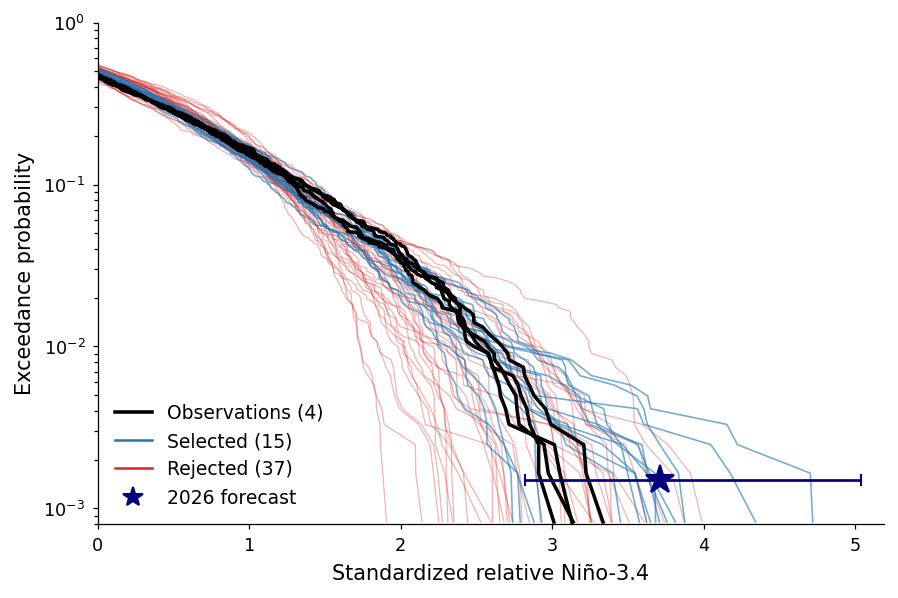

In [51]:
from matplotlib.lines import Line2D

def survival(s):
    x = np.sort(s); return x, 1 - np.arange(1, len(x)+1)/(len(x)+1)

fig, ax = plt.subplots(figsize=(6, 4))
for m, s in model_rel.items():
    if m not in gate:
        x, p = survival(s); ax.plot(x, p, color="tab:red", lw=0.6, alpha=0.35)
for m in gate:
    x, p = survival(model_rel[m]); ax.plot(x, p, color="tab:blue", lw=0.8, alpha=0.6)
for n, s in obs_rel.items():
    x, p = survival(s); ax.plot(x, p, color="k", lw=1.7)

ax.set_yscale("log"); ax.set_xlim(0, 4); ax.set_ylim(8e-4, 1)
ax.set_xlabel("Standardized relative Niño-3.4", fontsize=10)
ax.set_ylabel("Exceedance probability", fontsize=10)
# ax.set_title("Upper-tail exceedance: obs vs selected vs rejected")

ax.legend(handles=[
    Line2D([0], [0], color="k",        lw=1.7, label="Observations (4)"),
    Line2D([0], [0], color="tab:blue", lw=1.2, label=f"Selected ({len(gate)})"),
    Line2D([0], [0], color="tab:red",  lw=1.2, label=f"Rejected ({len(model_rel)-len(gate)})"),
], frameon=False, loc="lower left", fontsize=9)



ax.errorbar(zc, 1.5e-3, xerr=[[zc - zlo], [zhi - zc]], fmt="*", ms=14,
            color="navy", mec="navy", capsize=3, lw=1.3, zorder=6, label="2026 forecast")
ax.set_xlim(0, max(4, zhi * 1.03))          # extend x if the high whisker runs past 4
# then rebuild the legend to include it:
ax.legend(handles=[Line2D([0],[0], color="k", lw=1.7, label="Observations (4)"),
                   Line2D([0],[0], color="tab:blue", lw=1.2, label=f"Selected ({len(gate)})"),
                   Line2D([0],[0], color="tab:red",  lw=1.2, label=f"Rejected ({len(model_rel)-len(gate)})"),
                   Line2D([0],[0], color="navy", marker="*", ls="", ms=10, label="2026 forecast")],
          frameon=False, loc="lower left", fontsize=9)

plt.tight_layout(); plt.show()

In [ ]:
% 

In [47]:
def obs_oni_std(n):                                   # obs RONI std = obs ONI std (by construction)
    da  = std_obs(open_obs(n)).sel(time=slice("1900","2000"))
    n34 = da.sel(lat=slice(-5,5), lon=slice(190,240))
    n34 = n34.weighted(np.cos(np.deg2rad(n34.lat))).mean(("lat","lon"), skipna=True)
    oni = (n34.groupby("time.month") - n34.groupby("time.month").mean("time")).rolling(time=3, center=True).mean()
    return float(oni.std())
SIGMA_OBS = float(np.mean([obs_oni_std(n) for n in obs_files]))
print(f"SIGMA_OBS (observed RONI std, 1900–2000) = {SIGMA_OBS:.3f}")

def std_coords(ds):
    da = ds["ts"]; ren = {}
    for c in list(da.coords):
        cl = c.lower()
        if cl in ("latitude","lat","y"):  ren[c] = "lat"
        elif cl in ("longitude","lon","x"): ren[c] = "lon"
    da = da.rename(ren)
    return da.assign_coords(lon=(da["lon"] % 360)).sortby("lon").sortby("lat")

def rel_from_files(files, period=None):
    ds = xr.open_mfdataset(files, combine="by_coords", use_cftime=True, chunks={"time": 120})
    da = std_coords(ds)
    if period: da = da.sel(time=period)
    ocean = np.isnan(_LAND.mask(da.lon, da.lat))
    return rel_n34(da, ocean)

hist_std = {}
for m in tqdm(gate):
    hist_std[m] = float(rel_from_files(hist[m]["files"], slice("1900","2000")).compute().std())
factor = {m: SIGMA_OBS / hist_std[m] for m in gate}
print(pd.Series(factor).round(2).sort_values().to_string())

SIGMA_OBS (observed RONI std, 1900–2000) = 0.786


  0%|          | 0/15 [00:00<?, ?it/s]

CESM2-WACCM-FV2     0.64
CESM2-WACCM         0.81
CMCC-CM2-HR4        0.90
MRI-ESM2-0          0.93
E3SM-1-0            0.99
IPSL-CM6A-LR        1.00
FIO-ESM-2-0         1.01
GISS-E2-1-H         1.01
E3SM-1-1-ECA        1.04
SAM0-UNICON         1.06
GFDL-CM4            1.09
EC-Earth3-Veg-LR    1.23
MPI-ESM1-2-LR       1.33
NESM3               1.41
INM-CM4-8           2.39


In [48]:
def event_peaks(roni):
    """One peak per ENSO year (Jul–Jun) = event magnitude."""
    roni = roni.dropna("time")
    mon  = roni["time"].dt.month.values
    yr   = roni["time"].dt.year.values
    eyr  = np.where(mon >= 7, yr, yr - 1)
    return pd.Series(roni.values, index=eyr).groupby(level=0).max().values

pic_peaks = {}
for m in tqdm([g for g in gate if g in avail["piControl"]]):
    roni = (rel_from_files(avail["piControl"][m]["files"]).compute()) * factor[m]
    pic_peaks[m] = event_peaks(roni)

print("\npiControl: model, n ENSO-years, max event RONI:")
for m, pk in pic_peaks.items():
    print(f"  {m:22s} {len(pk):5d} yr   max {np.nanmax(pk):.2f}")

  0%|          | 0/14 [00:00<?, ?it/s]


piControl: model, n ENSO-years, max event RONI:
  CESM2-WACCM              500 yr   max 2.89
  CESM2-WACCM-FV2          501 yr   max 2.11
  E3SM-1-0                 501 yr   max 2.85
  E3SM-1-1-ECA             252 yr   max 2.68
  EC-Earth3-Veg-LR         502 yr   max 2.85
  FIO-ESM-2-0              501 yr   max 3.49
  GFDL-CM4                 501 yr   max 2.79
  GISS-E2-1-H              802 yr   max 2.38
  INM-CM4-8                532 yr   max 2.90
  IPSL-CM6A-LR            2001 yr   max 2.72
  MPI-ESM1-2-LR           1001 yr   max 4.12
  MRI-ESM2-0               702 yr   max 2.36
  NESM3                    501 yr   max 3.15
  SAM0-UNICON              701 yr   max 3.80


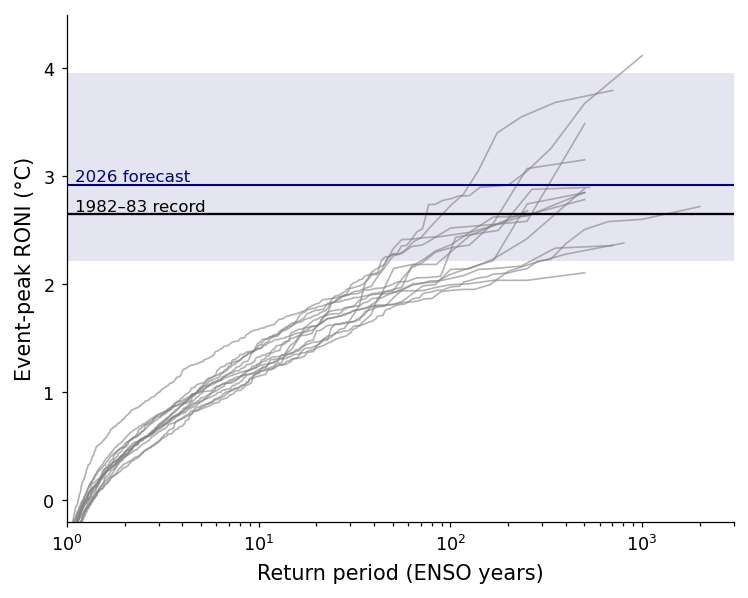

model                RP(2.65)   RP(3.11)
  CESM2-WACCM              501 yr    >500 yr
  CESM2-WACCM-FV2         >501 yr    >501 yr
  E3SM-1-0                 502 yr    >501 yr
  E3SM-1-1-ECA             253 yr    >252 yr
  EC-Earth3-Veg-LR         252 yr    >502 yr
  FIO-ESM-2-0              502 yr     502 yr
  GFDL-CM4                 502 yr    >501 yr
  GISS-E2-1-H             >802 yr    >802 yr
  INM-CM4-8                266 yr    >532 yr
  IPSL-CM6A-LR            2002 yr   >2001 yr
  MPI-ESM1-2-LR             77 yr     200 yr
  MRI-ESM2-0              >702 yr    >702 yr
  NESM3                    251 yr     251 yr
  SAM0-UNICON              100 yr     140 yr


In [72]:
import json
f2026 = json.load(open("/g/data/if69/as8561/data/f2026_roni_forecast.json"))
REC = 2.65   # 1982-83 observed record (multi-product central)

def return_curve(pk):
    x = np.sort(pk)[::-1]
    return (len(x)+1)/np.arange(1, len(x)+1), x     # return period (yr), magnitude
def return_period(pk, thr):
    n = np.sum(pk >= thr)
    return (len(pk)+1)/n if n else np.inf

fig, ax = plt.subplots(figsize=(5.0, 4.0))
for m, pk in pic_peaks.items():
    rp, x = return_curve(pk); ax.plot(rp, x, lw=0.8, alpha=0.6, color='gray')
ax.axhline(REC, color="k", ls="-", lw=1.1)
ax.text(1.1, REC+0.03, "1982–83 record", fontsize=8)
ax.axhspan(f2026["low"], f2026["high"], color="navy", alpha=0.1, lw=0.)
ax.axhline(f2026["best"], color="navy", ls="-", lw=1.0)
ax.text(1.1, f2026["best"]+0.03, "2026 forecast", color="navy", fontsize=8)
ax.set_xscale("log"); ax.set_xlim(1, 3000); ax.set_ylim(-0.2, 4.5)
ax.set_xlabel("Return period (ENSO years)", fontsize=10); ax.set_ylabel("Event-peak RONI (\u00b0C)", fontsize=10)
# ax.set_title("piControl: RONI event return periods (gated models)")
plt.tight_layout(); plt.show()

# return period of the record and the forecast in each model's unforced climate
print("model                RP(2.65)   RP(3.11)")
for m, pk in pic_peaks.items():
    rp1, rp2 = return_period(pk, REC), return_period(pk, f2026["best"])
    f = lambda r: f">{len(pk)}" if np.isinf(r) else f"{r:.0f}"
    print(f"  {m:20s} {f(rp1):>7s} yr {f(rp2):>7s} yr")

In [71]:
def process_experiment(expname):
    peaks = {}
    for m in tqdm([g for g in gate if g in avail[expname]], desc=expname):
        try:
            roni = rel_from_files(avail[expname][m]["files"]).compute() * factor[m]
            peaks[m] = event_peaks(roni)
        except Exception as e:
            tqdm.write(f"  {m} SKIP {type(e).__name__}: {str(e)[:50]}")
    return peaks

avail["historical"] = hist          # hist[m] already has {"grid","version","files"}

exp_peaks = {"piControl": pic_peaks}
for e in ["historical", "ssp245", "ssp585", "abrupt-4xCO2"]:
    exp_peaks[e] = process_experiment(e)
print({e: sum(len(v) for v in pk.values()) for e, pk in exp_peaks.items()}, "total ENSO-years")

historical:   0%|          | 0/15 [00:00<?, ?it/s]

ssp245:   0%|          | 0/9 [00:00<?, ?it/s]

ssp585:   0%|          | 0/9 [00:00<?, ?it/s]

abrupt-4xCO2:   0%|          | 0/13 [00:00<?, ?it/s]

{'piControl': 9498, 'historical': 2490, 'ssp245': 783, 'ssp585': 1382, 'abrupt-4xCO2': 2731} total ENSO-years


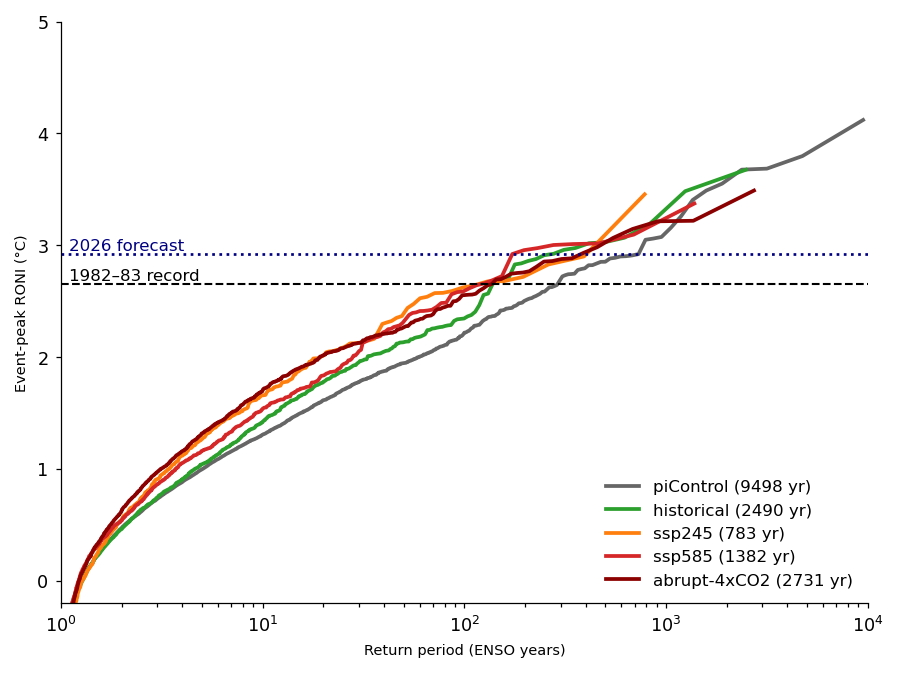

climate           RP(record)   RP(forecast)
  piControl           297 yr      731 yr
  historical          138 yr      277 yr
  ssp245              131 yr      784 yr
  ssp585              126 yr      173 yr
  abrupt-4xCO2        137 yr      390 yr


In [75]:
climates = ["piControl", "historical", "ssp245", "ssp585", "abrupt-4xCO2"]
colors   = {"piControl":"0.4","historical":"tab:green","ssp245":"tab:orange",
            "ssp585":"tab:red","abrupt-4xCO2":"darkred"}

fig, ax = plt.subplots(figsize=(6, 4.5))
for e in climates:
    allpk = np.concatenate(list(exp_peaks[e].values()))
    rp, x = return_curve(allpk)
    ax.plot(rp, x, lw=1.8, color=colors[e], label=f"{e} ({allpk.size} yr)")

ax.axhline(rec_c, color="k", ls="--", lw=1); ax.text(1.1, rec_c+0.03, "1982–83 record", fontsize=8)
ax.axhline(fc_c,  color="navy", ls=":", lw=1.3); ax.text(1.1, fc_c+0.03, "2026 forecast", color="navy", fontsize=8)
ax.set_xscale("log"); ax.set_xlim(1, 1e4); ax.set_ylim(-0.2, 5)
ax.set_xlabel("Return period (ENSO years)"); ax.set_ylabel("Event-peak RONI (\u00b0C)")
ax.legend(frameon=False, fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

# return period of the forecast magnitude in each climate
print("climate           RP(record)   RP(forecast)")
for e in climates:
    allpk = np.concatenate(list(exp_peaks[e].values()))
    print(f"  {e:14s} {return_period(allpk, rec_c):8.0f} yr {return_period(allpk, fc_c):8.0f} yr")

In [77]:

def n34_from_files(files):
    ds = xr.open_mfdataset(files, combine="by_coords", use_cftime=True, chunks={"time": 120})
    da = std_coords(ds)
    b  = da.sel(lat=slice(-5, 5), lon=slice(190, 240))
    return b.weighted(np.cos(np.deg2rad(b.lat))).mean(("lat", "lon"))

# fixed Niño-3.4 monthly climatology from historical 1900–2000, per model
n34_clim = {}
for m in tqdm(gate, desc="hist clim"):
    s = n34_from_files(hist[m]["files"]).sel(time=slice("1900", "2000")).compute()
    n34_clim[m] = s.groupby("time.month").mean("time")

def oni_peaks_exp(e):
    pk = {}
    for m in tqdm([g for g in gate if g in avail[e]], desc=e):
        try:
            s   = n34_from_files(avail[e][m]["files"]).compute()
            oni = (s.groupby("time.month") - n34_clim[m]).rolling(time=3, center=True).mean() * factor[m]
            pk[m] = event_peaks(oni)              # keeps the background warming in the anomaly
        except Exception as ex:
            tqdm.write(f"  {m} SKIP {type(ex).__name__}: {str(ex)[:50]}")
    return pk

oni_peaks = {e: oni_peaks_exp(e) for e in climates}

hist clim:   0%|          | 0/15 [00:00<?, ?it/s]

piControl:   0%|          | 0/14 [00:00<?, ?it/s]

historical:   0%|          | 0/15 [00:00<?, ?it/s]

ssp245:   0%|          | 0/9 [00:00<?, ?it/s]

ssp585:   0%|          | 0/9 [00:00<?, ?it/s]

abrupt-4xCO2:   0%|          | 0/13 [00:00<?, ?it/s]

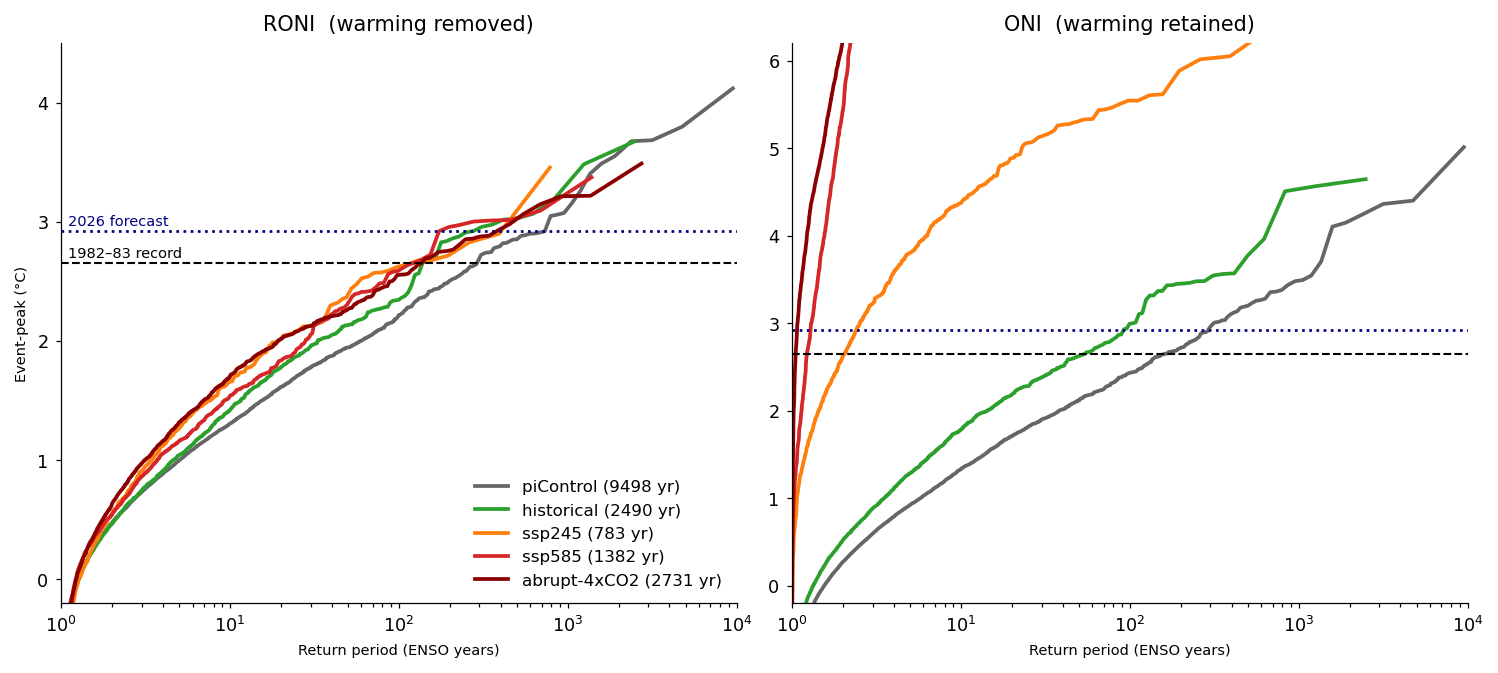

                RP(record)              RP(forecast)
                RONI      ONI           RONI      ONI
  piControl         297    167 yr        731    297 yr
  historical        138     55 yr        277     92 yr
  ssp245            131      2 yr        784      2 yr
  ssp585            126      1 yr        173      1 yr
  abrupt-4xCO2      137      1 yr        390      1 yr


In [82]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, pkdict, ttl, ymax in [(axes[0], exp_peaks, "RONI  (warming removed)", 4.5),
                              (axes[1], oni_peaks, "ONI  (warming retained)", 6.2)]:
    for e in climates:
        allpk = np.concatenate(list(pkdict[e].values()))
        rp, x = return_curve(allpk)
        ax.plot(rp, x, color=colors[e], lw=1.8, label=f"{e} ({allpk.size} yr)")
    ax.axhline(rec_c, color="k", ls="--", lw=1)
    ax.axhline(fc_c,  color="navy", ls=":", lw=1.3)
    ax.set_xscale("log"); ax.set_xlim(1, 1e4); ax.set_ylim(-0.2, ymax)
    ax.set_xlabel("Return period (ENSO years)"); ax.set_title(ttl, fontsize=10)
axes[0].set_ylabel("Event-peak (\u00b0C)")
axes[0].text(1.1, rec_c+0.05, "1982\u201383 record", fontsize=7)
axes[0].text(1.1, fc_c+0.05, "2026 forecast", color="navy", fontsize=7)
axes[0].legend(frameon=False, fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

print("                RP(record)              RP(forecast)")
print("                RONI      ONI           RONI      ONI")
for e in climates:
    aR = np.concatenate(list(exp_peaks[e].values()))
    aO = np.concatenate(list(oni_peaks[e].values()))
    g = lambda pk, thr: "\u221e" if not (pk >= thr).any() else f"{return_period(pk, thr):.0f}"
    print(f"  {e:14s} {g(aR,rec_c):>6s} {g(aO,rec_c):>6s} yr     "
          f"{g(aR,fc_c):>6s} {g(aO,fc_c):>6s} yr")

1. Build the index. For each model and experiment, compute monthly relative Niño-3.4 (Niño-3.4 area-mean anomaly minus the ocean-masked 20°S–20°N mean anomaly), then a 3-month running mean. For the ONI companion, skip the tropical-mean subtraction and anomalize against a fixed 1900–2000 baseline so warming accumulates.

2. Put models on the observed scale. Each model gets one multiplicative factor, σ_obs / σ_model, computed from historical 1900–2000. One factor per model applied to all its experiments — so absolute thresholds mean something, while forced changes between experiments are preserved.

3. Reduce to one event per year. Group months into ENSO years (Jul–Jun) and take the maximum index value in each. That gives a series of annual event peaks — this is the "block maxima" step, with the block being one ENSO year.

4. Rank and count. Sort the peaks in descending order. The m-th largest of n peaks has an empirical exceedance probability of m/(n+1), so its return period is (n+1)/m years. Plotting magnitude against that gives the return-period curve. Equivalently, for any threshold: return period = total years ÷ number of years exceeding it.

5. Aggregate across models. Two options we ran — pooled (concatenate all model-years into one sample; long runs like IPSL's 2000 yr carry more weight, but you get smooth deep tails), or equal-weight (compute each model's exceedance rate, take the median across models with a 25–75% inter-model band; no single run dominates).

